# Download and prepare the document images

Everything in this project starts from the scanned daily-rainfall registers held by the Met Office [National Meteorological Library and Archive](https://digital.nmla.metoffice.gov.uk/index.php?name=SO_51194883-b9dd-4e27-93db-958f8fbea38b) (NMLA). The archive is organised as a tree of folders: the *England & Wales* collection contains one folder per decade, and each decade folder contains one document per county (large counties are split into several parts or boxes). Each document is a single multi-page PDF, and every page holds one station-year rainfall table.

The extraction pipeline works on single-page JPEG images named like `DRain_1871-1880_Cornwall-59.jpg` (county document, zero-based page number). Turning the archive into those images is a two-step process, documented here:

1. **Download** every document PDF from the archive (`scripts/download_documents.py`).
2. **Split** each PDF into zero-based per-page JPEG images (`scripts/split_documents.py`).

A final optional step trims the scanned margins and separates regular from irregular pages (`scripts/preprocess_images.py`).

The full collection is hundreds of gigabytes, so the download and split steps are resumable and support cluster sharding. The cells below run a small demo on the earliest (smallest) decade; the markdown notes how to scale each step to the whole collection.

> **Licence.** The NMLA daily-rainfall collection is published under the [Open Government Licence](https://www.nationalarchives.gov.uk/doc/open-government-licence/). Please crawl politely — the scripts use a conservative default request delay.


## Configuration

Set the archive root, the local output directories, and a small helper to run the preparation scripts as command-line tools. For a real run, point `DATA_ROOT` at a large-capacity location (for the full pipeline this is an Azure datastore path, not the repository).


In [1]:
import subprocess
import sys
from pathlib import Path

# Locate the repository root (the folder containing `scripts/`).
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "scripts").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
SCRIPTS = REPO_ROOT / "scripts"

# Local output locations for this demo. For the full collection use a
# large-capacity path (an Azure datastore for the production pipeline).
DATA_ROOT = REPO_ROOT / "document_archive"
DOCUMENTS_DIR = DATA_ROOT / "documents"  # downloaded PDFs
IMAGES_DIR = DATA_ROOT / "images"        # per-page JPEGs

# Archive folder identifiers.
COLLECTION_ROOT = "SO_51194883-b9dd-4e27-93db-958f8fbea38b"  # England & Wales
DEMO_ROOT = "SO_6f691f4f-d172-443b-97eb-4b1d54fe33e7"        # DRain_1860-earlier


def run(args):
    """Run a preparation script with the notebook's Python interpreter."""
    cmd = [sys.executable, *[str(a) for a in args]]
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, cwd=REPO_ROOT)
    print(f"[exit code {result.returncode}]")
    return result.returncode


REPO_ROOT


PosixPath('/home/users/philip.brohan/Projects/Auto-Daily-Rainfall-MO')

## Survey the collection

Before downloading anything, walk the folder tree and build a manifest of every document. This is a dry run — it lists the archive but downloads no files. The manifest records each document's identifier, title, and containing folder, and lets us see how the ~thousands of documents are distributed across the decades.


In [ ]:
import json
from collections import Counter

manifest_path = DATA_ROOT / "manifest.json"

# Survey the whole England & Wales collection (network-only, no downloads).
run([
    SCRIPTS / "download_documents.py",
    "--output", DOCUMENTS_DIR,
    "--root", COLLECTION_ROOT,
    "--dry-run",
    "--manifest", manifest_path,
])

documents = json.loads(manifest_path.read_text())
print(f"\nTotal documents: {len(documents)}\n")

by_decade = Counter(doc["title"].split("_")[1] for doc in documents)
for decade in sorted(by_decade):
    print(f"  {decade:16s} {by_decade[decade]:5d} documents")


## Download the documents

`scripts/download_documents.py` crawls the folder tree and downloads every document PDF. Downloads are **idempotent and resumable**: a file that already exists is skipped, and each download is written to a temporary file and atomically renamed on success, so an interrupted run can simply be re-run.

The cell below downloads a small slice of the earliest decade as a demo. To fetch the **whole collection**, drop the `--root`/`--shard` arguments:

```bash
conda activate weather-doc-extractor
python scripts/download_documents.py --output /path/to/documents
```

On a cluster, split the work across jobs with `--shard INDEX TOTAL`, which distributes the documents round-robin over `TOTAL` jobs.


In [2]:
# Demo: download one shard (a couple of small documents) from the earliest decade.
# Remove --root and --shard to download the entire collection.
run([
    SCRIPTS / "download_documents.py",
    "--output", DOCUMENTS_DIR,
    "--root", DEMO_ROOT,
    "--shard", "0", "20",
])

pdfs = sorted(DOCUMENTS_DIR.glob("*.pdf"))
print(f"\n{len(pdfs)} document(s) in {DOCUMENTS_DIR}:")
for pdf in pdfs:
    print(f"  {pdf.name}  ({pdf.stat().st_size / 1e6:.1f} MB)")


$ /data/users/philip.brohan/conda/environments/weather-doc-extractor/bin/python /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-MO/scripts/download_documents.py --output /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-MO/document_archive/documents --root SO_6f691f4f-d172-443b-97eb-4b1d54fe33e7 --shard 0 20


2026-07-29 16:46:28,158 - INFO - Enumerating documents under SO_6f691f4f-d172-443b-97eb-4b1d54fe33e7 ...
2026-07-29 16:46:28,159 - INFO - Listing folder root (SO_6f691f4f-d172-443b-97eb-4b1d54fe33e7)
2026-07-29 16:46:30,644 - INFO - Found 14 documents
2026-07-29 16:46:30,645 - INFO - Shard 0/20: 1 documents
2026-07-29 16:46:33,121 - INFO - Downloaded DRain_Pre-1860_Berkshire.pdf (17851489 bytes)


[exit code 0]

1 document(s) in /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-MO/document_archive/documents:
  DRain_Pre-1860_Berkshire.pdf  (17.9 MB)


2026-07-29 16:46:34,122 - INFO - Done: 1 downloaded, 0 skipped, 0 failed


## Split the documents into page images

`scripts/split_documents.py` renders each PDF to single-page JPEGs using `pdftoppm`, naming them `<document-stem>-<page>.jpg` with **zero-based** page numbers to match the training and sample data. Like the download step, it is idempotent (documents whose pages are all present are skipped) and supports `--workers` for local parallelism and `--shard` for the cluster.

The image dpi does matter - too low and the images are not readable; too high and they take too many tokens => expensive to process. 75 dpi seems a reasonable compromise for these images, but I have not tried to optimise this.


In [ ]:
run([
    SCRIPTS / "split_documents.py",
    "--source", DOCUMENTS_DIR,
    "--output", IMAGES_DIR,
    "--dpi", "75",
    "--workers", "4",
])

images = sorted(IMAGES_DIR.glob("*.jpg"))
print(f"\n{len(images)} page image(s) in {IMAGES_DIR}")
for image in images[:5]:
    print(f"  {image.name}")


$ /data/users/philip.brohan/conda/environments/weather-doc-extractor/bin/python /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-MO/scripts/split_documents.py --source /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-MO/document_archive/documents --output /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-MO/document_archive/images --dpi 150 --workers 4


2026-07-29 16:46:40,195 - INFO - Splitting 1 PDFs with 4 workers


[exit code 0]

17 page image(s) in /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-MO/document_archive/images
  DRain_Pre-1860_Berkshire-0.jpg
  DRain_Pre-1860_Berkshire-1.jpg
  DRain_Pre-1860_Berkshire-10.jpg
  DRain_Pre-1860_Berkshire-11.jpg
  DRain_Pre-1860_Berkshire-12.jpg


2026-07-29 16:46:45,921 - INFO - Split DRain_Pre-1860_Berkshire into 17 pages
2026-07-29 16:46:45,927 - INFO - Done: 1 split, 0 skipped, 0 failed


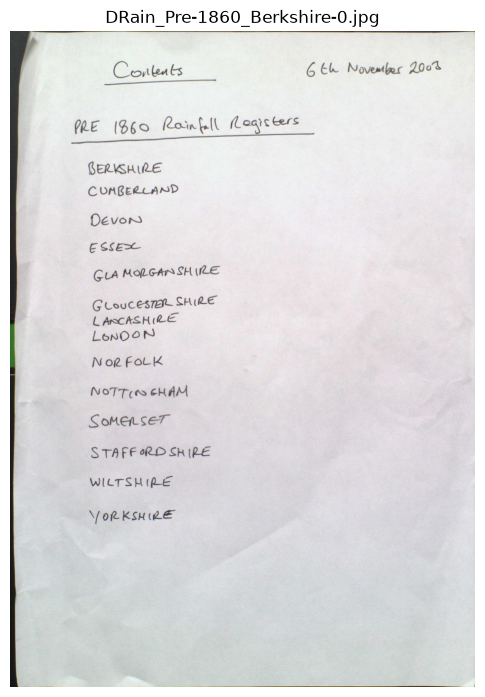

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

if images:
    sample = Image.open(images[0])
    plt.figure(figsize=(6, 9))
    plt.imshow(sample)
    plt.title(images[0].name)
    plt.axis("off")
    plt.show()


## Trim and categorise the pages (optional)

The rendered pages still carry the scanned margins. `scripts/preprocess_images.py` trims surrounding whitespace and sorts pages into *regular* (portrait rainfall tables) and *irregular* (covers, indexes, odd sizes) so that only the useful tables flow into the extraction stages.


In [ ]:
run([
    SCRIPTS / "preprocess_images.py",
    "--source", IMAGES_DIR,
    "--output-filtered", DATA_ROOT / "filtered",
    "--output-irregular", DATA_ROOT / "irregular",
    "--workers", "4",
])


## Scaling to the full collection

The whole England & Wales collection is far too large to download on a single machine in one pass. For the production run:

- Store the documents and images on a large-capacity path (an Azure datastore for this project, not the repository).
- Split each step across cluster jobs with `--shard INDEX TOTAL`. Because the document and PDF lists are sorted deterministically, the same shard index always covers the same files, so jobs can be re-run safely.
- All three scripts are idempotent, so a partially complete run is resumed simply by launching it again.

```bash
conda activate weather-doc-extractor

# 1. Download every document PDF (shard 0 of 6 shown)
python scripts/download_documents.py --output $DOCS --shard 0 6

# 2. Split PDFs into zero-based per-page JPEGs
python scripts/split_documents.py --source $DOCS --output $IMAGES --shard 0 6

# 3. Trim margins and separate regular from irregular pages
python scripts/preprocess_images.py --source $IMAGES \
    --output-filtered $FILTERED --output-irregular $IRREGULAR --shard 0 6
```

With the images prepared, continue to the zeroth-order notebooks to run the first extractions.
